In [39]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [40]:
import os

print(os.listdir())

['requirements.txt', '.ipynb_checkpoints', 'README.md', 'results', 'customer_support_text_classification.csv', 'notebook.ipynb', 'data_dictionary.md']


In [41]:
df = pd.read_csv("customer_support_text_classification.csv")

In [42]:
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [43]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1500, 6)


In [44]:
print(df.columns)

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


In [45]:
print(df['customer_message'][0])

I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.


In [46]:
df['text_length'] = df['customer_message'].apply(len)

print(df['text_length'].mean())

72.75666666666666


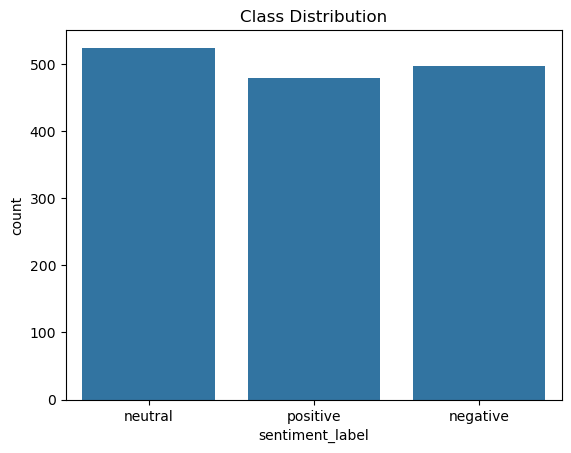

In [47]:
sns.countplot(x='sentiment_label', data=df)

plt.title('Class Distribution')

plt.show()

In [48]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    return text

In [51]:
df['clean_message'] = df['customer_message'].apply(clean_text)

In [52]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):

    words = text.split()

    filtered = [word for word in words if word not in stop_words]

    return " ".join(filtered)

In [53]:
df['clean_message'] = df['clean_message'].apply(remove_stopwords)

In [54]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_message']).toarray()

y = df['sentiment_label']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [57]:
y_pred = model.predict(X_test)

In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [60]:
os.makedirs('results', exist_ok=True)

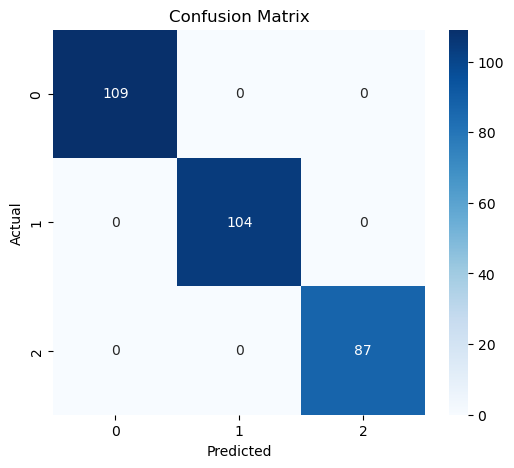

In [61]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig('results/confusion_matrix.png')

plt.show()

In [62]:
evaluation = pd.DataFrame({
    'Metric': ['Accuracy'],
    'Value': [accuracy_score(y_test, y_pred)]
})

evaluation.to_csv('results/model_evaluation.csv', index=False)

In [63]:
sample_df = pd.DataFrame({
    'Actual': y_test.iloc[:10].values,
    'Predicted': y_pred[:10]
})

sample_df.to_csv('results/sample_predictions.txt', index=False)

In [64]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_message'])

In [65]:
sequences = tokenizer.texts_to_sequences(df['clean_message'])

In [66]:
X_seq = pad_sequences(sequences, maxlen=100)

In [67]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train_seq = encoder.fit_transform(y_train_seq)
y_test_seq = encoder.transform(y_test_seq)

In [69]:
lstm_model = Sequential([
    
    Embedding(input_dim=5000, output_dim=64),
    
    LSTM(64),
    
    Dense(3, activation='softmax')
])

In [70]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [71]:
lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.6062 - loss: 0.9972 - val_accuracy: 0.7417 - val_loss: 0.7539
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8313 - loss: 0.6081 - val_accuracy: 0.9792 - val_loss: 0.2587
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9917 - loss: 0.1555 - val_accuracy: 1.0000 - val_loss: 0.0570
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 1.0000 - loss: 0.0343 - val_accuracy: 1.0000 - val_loss: 0.0179
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 1.0000 - loss: 0.0140 - val_accuracy: 1.0000 - val_loss: 0.0100


In [74]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 1.0000 - loss: 0.0086 - val_accuracy: 1.0000 - val_loss: 0.0065
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 0.0024


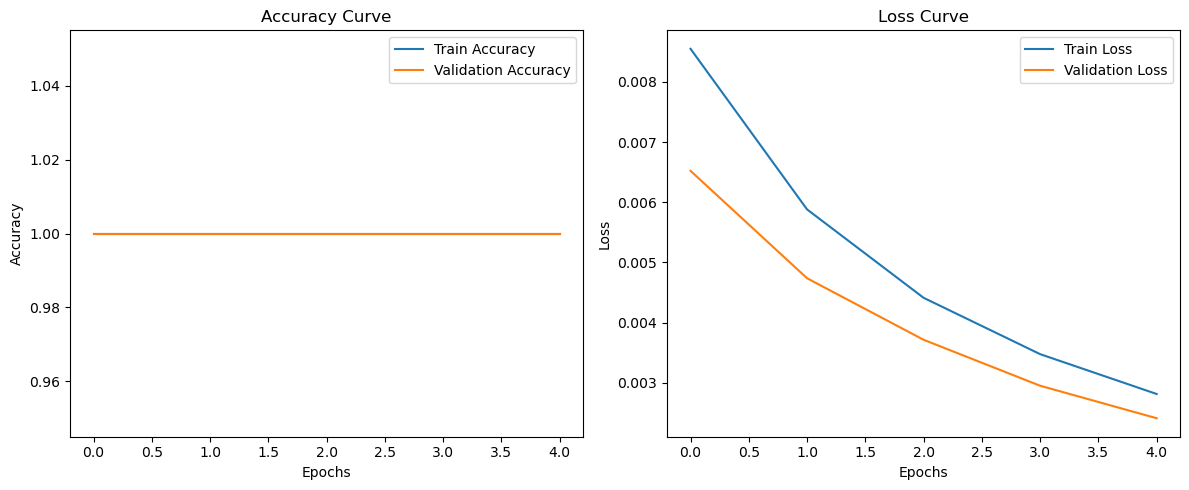

In [75]:
plt.figure(figsize=(12,5))

# Accuracy Curve
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

# Loss Curve
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

plt.tight_layout()

plt.savefig('results/lstm_training_curves.png')

plt.show()